In [1]:
import matplotlib.pyplot as plt
import os
import json
import numpy as np

In [2]:
def get_losses(best_path, dist=True):
    
    train_losses_path = os.path.join(best_path, 'losses.train')
    with open(train_losses_path, 'r') as f:
        train_losses = np.array(json.load(f))
    # print(train_losses)
        
    val_losses_path = os.path.join(best_path, 'losses.val')
    with open(val_losses_path, 'r') as f:
        val_losses = np.array(json.load(f))
    # print(val_losses)
        
    bug_losses_path = os.path.join(best_path, 'losses.bugs')
    with open(bug_losses_path, 'r') as f:
        bug_losses = np.array(json.load(f))
    # print(bug_losses)
        
    total_losses_path = os.path.join(best_path, 'losses.total')
    with open(total_losses_path, 'r') as f:
        total_losses = np.array(json.load(f))
    # print(total_losses)
    
    if dist:
        distillation_losses_path = os.path.join(best_path, 'losses.dist')
        with open(distillation_losses_path, 'r') as f:
            distillation_losses = np.array(json.load(f))
            
        return train_losses, val_losses, bug_losses, total_losses, distillation_losses
    else:  
        return train_losses, val_losses, bug_losses, total_losses

def get_weights(best_path, dist=True):
    
    train_weights_path = os.path.join(best_path, 'weights.train')
    with open(train_weights_path, 'r') as f:
        train_weights = json.load(f)
    # print(train_weights)
    
    bug_weights_path = os.path.join(best_path, 'weights.bugs')
    with open(bug_weights_path, 'r') as f:
        bug_weights = json.load(f)
        
    if dist:
        distillation_weights_path = os.path.join(best_path, 'weights.dist')
        with open(distillation_weights_path, 'r') as f:
            distillation_weights = json.load(f)
            
        return train_weights, bug_weights, distillation_weights
    else:
        return train_weights, bug_weights
    
    

def plot_losses(dir_path, title, max_val=None, save_path=None, dist=True, plot_individual=True):
    if dist:
        train_losses, val_losses, bug_losses, total_losses, distillation_losses = get_losses(dir_path, dist=True)
    else:
        train_losses, val_losses, bug_losses, total_losses = get_losses(dir_path, dist=False)
        
    if max_val is not None:
        # cap the values to the max_val
        train_losses = np.minimum(train_losses, max_val)
        val_losses = np.minimum(val_losses, max_val)
        bug_losses = np.minimum(bug_losses, max_val)
        if dist:
            distillation_losses = np.minimum(distillation_losses, max_val)
        total_losses = np.minimum(total_losses, max_val)
    
    plt.figure()
    plt.plot(train_losses, label='train', color='blue')
    plt.plot(val_losses, label='val', color='red',  linestyle='dotted')
    plt.plot(bug_losses, label='bugs', color='green')
    if dist:
        plt.plot(distillation_losses, label='distillation', color='orange')
    # plt.plot(total_losses, label='total', color='black')
    plt.title(title)
    # label axis
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    if save_path is not None:
        fig_name = title.replace(' ', '_').replace(',', '_').replace('=', '_').replace('.', '') + '.png'
        plt.savefig(save_path+fig_name, dpi=300, bbox_inches='tight',pad_inches=0.05)
    plt.show()
    
    if plot_individual:
        # individual plots
        plt.figure()
        plt.plot(train_losses, label='train', color='blue')
        plt.title(title + ', train loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        if save_path is not None:
            fig_name = str(title + ', train loss').replace(' ', '_').replace(',', '_').replace('=', '_').replace('.', '') + '.png'
            plt.savefig(save_path+fig_name, dpi=300, bbox_inches='tight',pad_inches=0.05)
        plt.show()
        
        plt.figure()
        plt.plot(val_losses, label='val', color='red')
        plt.title(title + ', val loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        if save_path is not None:
            fig_name = str(title + ', val loss').replace(' ', '_').replace(',', '_').replace('=', '_').replace('.', '') + '.png'
            plt.savefig(save_path+fig_name, dpi=300, bbox_inches='tight',pad_inches=0.05)
        plt.show()
        
        plt.figure()
        plt.plot(bug_losses, label='bugs', color='green')
        plt.title(title + ', bugs loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        if save_path is not None:
            fig_name = str(title + ', bugs loss').replace(' ', '_').replace(',', '_').replace('=', '_').replace('.', '') + '.png'
            plt.savefig(save_path+fig_name, dpi=300, bbox_inches='tight',pad_inches=0.05)
        plt.show()
        
        if dist:
            plt.figure()
            plt.plot(distillation_losses, label='distillation', color='orange')
            plt.title(title + ', distillation loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            if save_path is not None:
                fig_name = str(title + ', distillation loss').replace(' ', '_').replace(',', '_').replace('=', '_').replace('.', '') + '.png'
                plt.savefig(save_path+fig_name, dpi=300, bbox_inches='tight',pad_inches=0.05)
            plt.show()
        
        plt.figure()
        plt.plot(total_losses, label='total', color='black')
        plt.title(title + ', total loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        if save_path is not None:
            fig_name = str(title + ', total loss').replace(' ', '_').replace(',', '_').replace('=', '_').replace('.', '') + '.png'
            plt.savefig(save_path+fig_name, dpi=300, bbox_inches='tight',pad_inches=0.05)
        plt.show()
    
def plot_weights(dir_path, title, save_path=None, dist=True, max_val=None):
    if dist:
        train_weights, bug_weights, distillation_weights = get_weights(dir_path, dist=True)
    else:
        train_weights, bug_weights = get_weights(dir_path, dist=False)
    
    plt.figure()
    plt.plot(train_weights, label='train', color='blue')
    plt.plot(bug_weights, label='bugs', color='green')
    if dist:
        plt.plot(distillation_weights, label='distillation', color='orange')
    plt.title(title + ', weights')
    # label axis
    plt.xlabel('Epoch')
    plt.ylabel('Weight')
    plt.legend()
    if save_path is not None:
        fig_name = title.replace(' ', '_').replace(',', '_').replace('=', '_').replace('.', '') + '.png'
        plt.savefig(save_path+fig_name, dpi=300, bbox_inches='tight',pad_inches=0.05)
    plt.show()
    
    # also plot losses
    if dist:
        train_losses, val_losses, bug_losses, total_losses, distillation_losses = get_losses(dir_path, dist=True)
    else:
        train_losses, val_losses, bug_losses, total_losses = get_losses(dir_path, dist=False)
        
    if max_val is not None:
        # cap the values to the max_val
        train_losses = np.minimum(train_losses, max_val)
        bug_losses = np.minimum(bug_losses, max_val)
        if dist:
            distillation_losses = np.minimum(distillation_losses, max_val)
        
    plt.figure()
    plt.plot(train_losses, label='train', color='blue')
    plt.plot(bug_losses, label='bugs', color='green')
    if dist:
        plt.plot(distillation_losses, label='distillation', color='orange')
    plt.title(title + ', losses')
    # label axis
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    if save_path is not None:
        fig_name = title.replace(' ', '_').replace(',', '_').replace('=', '_').replace('.', '') + '.png'
        plt.savefig(save_path+fig_name, dpi=300, bbox_inches='tight',pad_inches=0.05)
    plt.show()

    

In [3]:
experiment_path = "/Users/nicola_mueller/Desktop/gnn-policy-kr22/test_distillation_blocks_self_distillation_random_init"
# plot_losses(experiment_path, "Blocks, Random Init, LR=0.0005", max_val=5, save_path="/Users/nicola_mueller/Desktop/loss_visualizations/Blocks_Random_Init/")

In [4]:
experiment_path = "/Users/nicola_mueller/Desktop/gnn-policy-kr22/test_distillation_blocks_self_distillation_no_random_init"
# plot_losses(experiment_path, "Blocks, Trained Policy Init, LR=0.001", max_val=5, save_path="/Users/nicola_mueller/Desktop/loss_visualizations/Blocks_Trained_Policy_Init/")

In [5]:
experiment_path = "/Users/nicola_mueller/Desktop/gnn-policy-kr22/test_distillation_delivery_no_random_init"
# plot_losses(experiment_path, "Delivery, Trained Policy Init, LR=0.001", max_val=5, save_path="/Users/nicola_mueller/Desktop/loss_visualizations/Delivery_Trained_Policy_Init/")

In [6]:
experiment_path = "/Users/nicola_mueller/Desktop/gnn-policy-kr22/test_distillation_delivery_random_init"
# plot_losses(experiment_path, "Delivery, Random Init, LR=0.0001", max_val=5, save_path="/Users/nicola_mueller/Desktop/loss_visualizations/Delivery_Random_Init/")

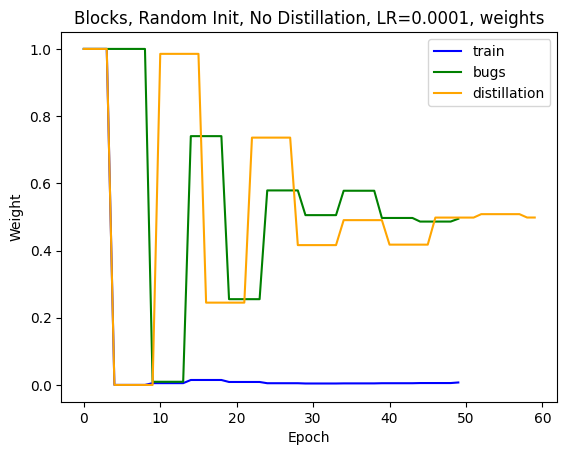

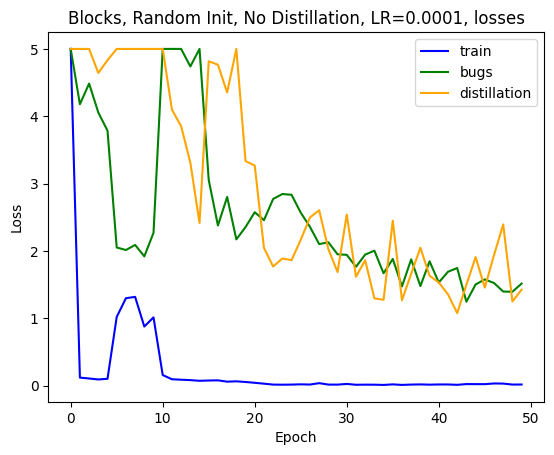

In [10]:
experiment_path = "/Users/nicola_mueller/Desktop/test_softadapt/testo/retrained/best_coverage_validation"
plot_weights(experiment_path, "Blocks, Random Init, No Distillation, LR=0.0001", save_path=None, dist=True, max_val=5)